# B29 Fleet MLP — 4-Cluster Diesel-Preisoptimierung

**CRISP-DM** | Studienprojekt HS Aalen – Predictive Analytics Sem 1

Ziel: 72-Stunden-Vorschau auf Dieselpreise an 4 Streckenclustern der B29 (Aalen → Stuttgart).
Die Flottenplanung sieht, zu welchem Zeitpunkt und in welchem Cluster in den nächsten 72 h am günstigsten getankt werden kann.

In [1]:
import sys, os
sys.path.insert(0, os.path.abspath('..'))

import warnings
warnings.filterwarnings('ignore', category=FutureWarning)

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import seaborn as sns
from IPython.display import display
from dotenv import load_dotenv

from sklearn.neural_network import MLPRegressor
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import TimeSeriesSplit
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

# ── Projekt-Skripte ────────────────────────────────────────────────────────
from scripts.viz_utils import (
    plot_price_timeseries,
    plot_intraday_by_region,
    plot_feature_list,
    plot_eval_mae_rmse,
    plot_actual_vs_predicted_14d,
    plot_cv_folds,
    plot_learning_curve,
    plot_residuals,
    plot_forecast_72h,
    plot_cost_sensitivity,
    plot_model_comparison,
)
from scripts.model_utils import (
    train_mlp,
    evaluate_model,
    run_architecture_comparison,
    compute_metrics_by_horizon,
    build_persistence_baseline,
    print_metrics_summary,
)
from scripts.data_transform import B29DataLoader, B29_CLUSTERS_DEFAULT

load_dotenv('../.env')
%matplotlib inline
sns.set_theme(style='whitegrid')
print('Imports OK')

Imports OK


---
## §1 — Business Understanding

### Szenario: Spedition mit 25 LKWs auf der B29 (Aalen → Stuttgart)

| Parameter | Wert |
|---|---|
| LKWs | 25 |
| Tagesfahrleistung | 500 km / LKW |
| Verbrauch | 30 L / 100 km |
| Tagesverbrauch Flotte | 3.750 L |
| Cluster | 4 (Aalen, Schwäbisch Gmünd, Schorndorf, Stuttgart) |
| Forecast-Horizont | 72 h |

**Ökonomische Motivation:**
Bei 5 ct/L Preisunterschied und 3.750 L Tagesverbrauch = **€ 187,50 / Tag** reines
Einsparpotenzial. Über 250 Arbeitstage summiert sich das auf **bis zu € 46.875 / Jahr**.

**Erfolgskennzahl:** MAE in ct/L und relative Verbesserung gegenüber der
Persistence-Baseline (aktueller Preis = naive Vorhersage).
---

In [2]:
# Spedition scenario constants
TRUCKS         = 25
KM_PER_DAY     = 500
CONSUMPTION    = 30
DAILY_LITERS   = TRUCKS * KM_PER_DAY * CONSUMPTION / 100
PRICE_SWING    = 0.05
TARGET_HORIZON = 72

print(f'Taeglicher Dieselbedarf : {DAILY_LITERS:,.0f} L')
print(f'Kosten bei 1.70 EUR/L  : {DAILY_LITERS * 1.70:,.2f} EUR')
print(f'Ersparnis bei 5ct/L    : {DAILY_LITERS * PRICE_SWING:,.2f} EUR / Tag')
print(f'Jaehrliches Potenzial  : {DAILY_LITERS * PRICE_SWING * 250:,.0f} EUR (250 Arbeitstage)')

Taeglicher Dieselbedarf : 3,750 L
Kosten bei 1.70 EUR/L  : 6,375.00 EUR
Ersparnis bei 5ct/L    : 187.50 EUR / Tag
Jaehrliches Potenzial  : 46,875 EUR (250 Arbeitstage)


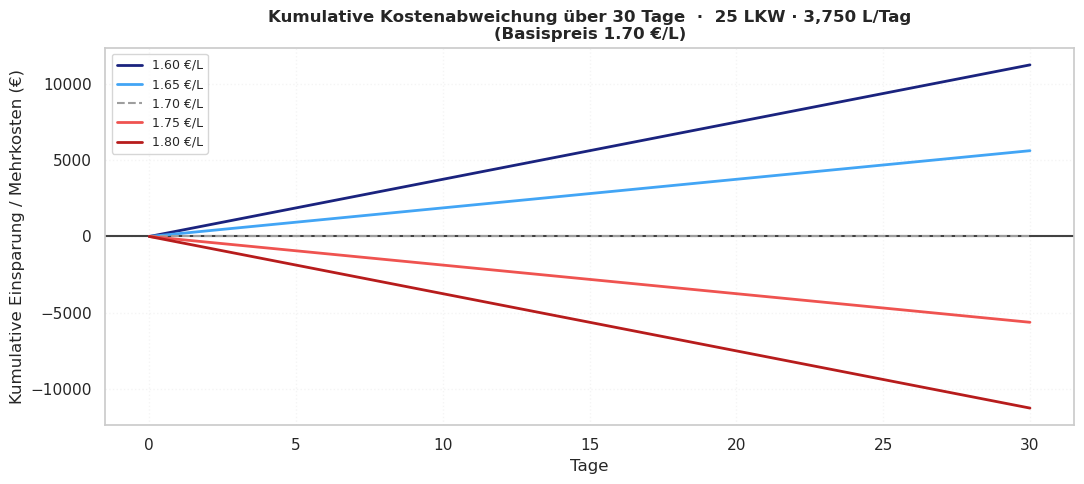

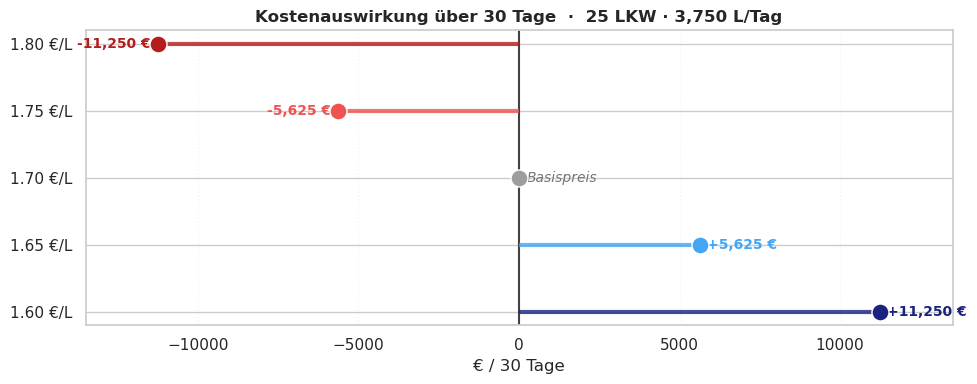

In [3]:
plot_cost_sensitivity(
    trucks=TRUCKS,
    daily_liters=DAILY_LITERS,
    price_base=1.70,
    price_scenarios=[1.60, 1.65, 1.70, 1.75, 1.80],
)

### Wirtschaftliche Relevanz

Eine Spedition betreibt **25 LKWs** auf der B29-Strecke zwischen Aalen und Stuttgart.
Mit **30 L / 100 km** und **500 km Tagesfahrleistung** verbraucht die Flotte täglich
rund **3.750 Liter Diesel**.

Bereits eine Preisänderung von **5 Cent pro Liter** führt zu einer Kostendifferenz von
**187,50 EUR pro Tag** — über 30 Tage sind das **5.625 EUR**.

Das MLP-Modell sagt die Dieselpreise an allen vier B29-Clustern für die nächsten
**72 Stunden** voraus und ermöglicht die gezielte Planung des optimalen Tankzeitpunkts.

---
## §2 — Data Understanding: B29-Cluster

Tankerkönig liefert event-basierte Preisänderungen (~327k/Tag, gesamt 87 GB).
Die vier B29-Cluster werden nach PLZ gefiltert und stündlich gemittelt (Event-Mean-Ansatz).

> **ELI5 — Was ist ein Cluster?**
>
> Die B29 führt durch mehrere Orte. Statt jede Tankstelle einzeln zu betrachten,
> fassen wir Tankstellen in derselben Region (nach Postleitzahl) zu einem
> **Cluster** zusammen — wie ein Durchschnittspreis für die Region.
> Das glättet Ausreißer und ist robuster als Einzelstationen.
---

In [4]:
# Cluster-Definitionen
print('B29-Cluster (PLZ-Gruppen):')
for name, plzs in B29_CLUSTERS_DEFAULT.items():
    print(f'  {name:24s}: {plzs}')

B29-Cluster (PLZ-Gruppen):
  Aalen                   : [73430, 73431, 73432, 73433, 73434]
  Schwäbisch Gmünd        : [73525, 73526, 73527, 73528, 73529]
  Schorndorf              : [73614, 73655, 73660, 71334, 71336]
  Stuttgart               : [70173, 70174, 70176, 70178, 70180, 70182, 70184, 70186, 70188, 70190, 70191, 70192, 70193, 70195, 70197, 70199, 70327, 70329, 70372, 70374, 70376, 70378, 70435, 70437, 70439, 70469, 70476, 70499, 70563, 70565, 70567, 70569, 70597, 70599, 70619, 70629]


In [5]:
# Cell 2a — Daten laden
loader = B29DataLoader(
    stride=0,
    forecast_horizon=TARGET_HORIZON,
    fuel_type='diesel',
    cache=True,
    debug=True,
)
X, y = loader.load()

# Basis-Cluster und t+1h-Targets fuer EDA
base_targets = sorted({c.rsplit('_t+', 1)[0] for c in y.columns})
y_t1 = y[[f'{c}_t+1h' for c in base_targets]].copy()
y_t1.columns = base_targets

print(f'\nZeitraum : {y.index[0]}  ->  {y.index[-1]}')
print(f'Cluster  : {base_targets}')
print(f'Targets  : {y.shape[1]}  ({len(base_targets)} Cluster x {TARGET_HORIZON} Horizonte)')
print(f'Features : {X.shape[1]}')

[B29DataLoader] DEBUG mode enabled
[B29DataLoader] Scanning stations …
[DEBUG] Loading stations from /home/jawasch/Documents/HS_Aalen/Sem1/PredictiveAnalytics/Projekt/tankerkoenig-data/stations/stations.csv
[DEBUG] Found 120 stations in B29 clusters: cluster
Stuttgart           73
Schorndorf          18
Aalen               16
Schwäbisch Gmünd    13
Name: count, dtype: int64
  Station counts per B29 cluster:
    Aalen                 :  16 stations
    Schorndorf            :  18 stations
    Schwäbisch Gmünd      :  13 stations
    Stuttgart             :  73 stations

[B29DataLoader] Loading raw prices for 120 stations …
[DEBUG] Searching for prices in /home/jawasch/Documents/HS_Aalen/Sem1/PredictiveAnalytics/Projekt/tankerkoenig-data/prices
[DEBUG] Found 4365 price files
[DEBUG] Loaded 9,840,176 price events for diesel
[DEBUG] Date range: 2014-06-08 07:50:01+00:00 to 2026-05-20 21:40:28+00:00
  9,840,176 price events loaded
[B29DataLoader] Aggregating to hourly cluster means …
[DEBUG

/home/jawasch/Documents/HS_Aalen/Sem1/PredictiveAnalytics/Projekt/Test_Spritpreise/scripts/data_transform.py:350: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  df[target_col] = df[col].shift(-step)
/home/jawasch/Documents/HS_Aalen/Sem1/PredictiveAnalytics/Projekt/Test_Spritpreise/scripts/data_transform.py:350: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  df[target_col] = df[col].shift(-step)
/home/jawasch/Documents/HS_Aalen/Sem1/PredictiveAnalytics/Projekt/Test_Spritpreise/scripts/data_transform.py:350: PerformanceWarning: Data

[B29DataLoader] Feature matrix ready: X=(104511, 80), y=(104511, 288)

Zeitraum : 2014-06-15 09:00:00  ->  2026-05-17 23:00:00
Cluster  : ['diesel_Aalen', 'diesel_Schorndorf', 'diesel_Schwäbisch Gmünd', 'diesel_Stuttgart']
Targets  : 288  (4 Cluster x 72 Horizonte)
Features : 80


In [6]:
y_t1.describe().round(4)

,diesel_Aalen,diesel_Schorndorf,diesel_Schwäbisch Gmünd,diesel_Stuttgart
count,104511.0000,104511.0000,104511.0000,104511.0000
mean,1.4208,1.4238,1.4262,1.4204
std,0.2973,0.3002,0.2984,0.2976
min,0.9140,0.9090,0.8790,0.9090
25%,1.1890,1.1840,1.1890,1.1890
50%,1.3190,1.3266,1.3290,1.3230
75%,1.6278,1.6390,1.6384,1.6313
max,2.5081,5.0035,2.4960,9.9990


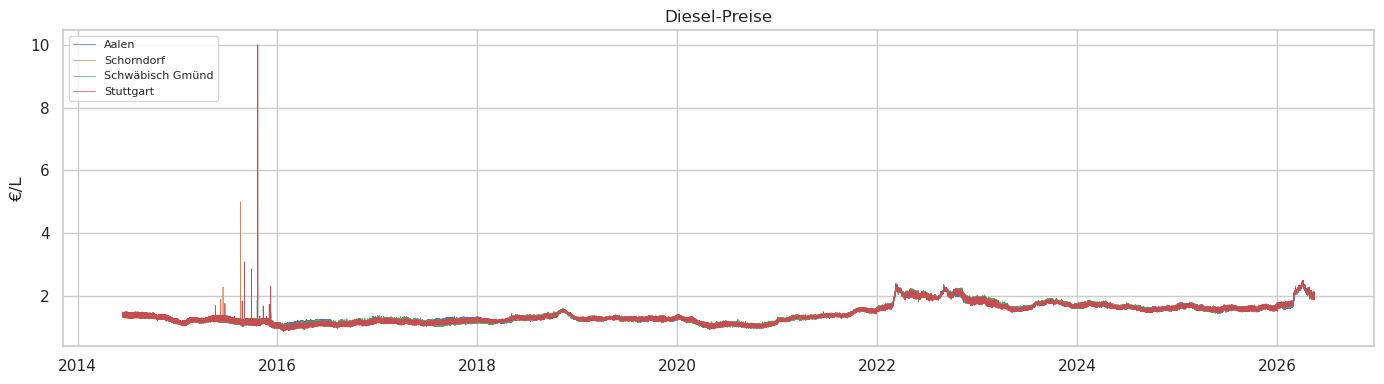

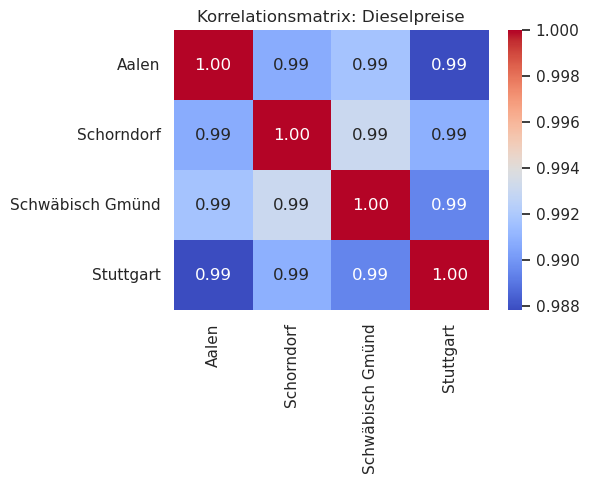

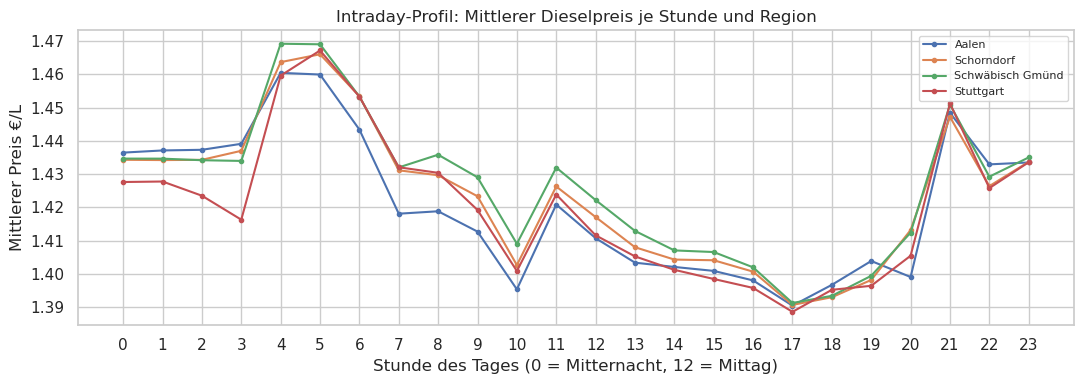

In [7]:
# Zeitlicher Verlauf und Intraday-Profil
plot_price_timeseries(y_t1, fuel_type='diesel')
plot_intraday_by_region(y_t1, fuel_type='diesel')

---
## §3 — Data Preparation

Der `B29DataLoader` berechnet alle Features automatisch (Lags, Rolling, Trend,
Momentum, Zeitmerkmale). Hier prüfen wir die Feature-Matrix und führen den
zeitlichen Split durch.

> **ELI5 — Warum bereiten wir Daten vor, bevor das Modell lernt?**
>
> Stell dir vor, du willst einem Kind beibringen, Fahrrad zu fahren.
> Du erklärst zuerst die Regeln: "Das ist das Lenkrad, das sind die Pedale."\n> Diese Erklärungen sind die **Features (X)**. Dann sagst du das Ziel:
> "Am Ende sollst du geradeaus fahren." Das ist **y**.\n>
> Der **StandardScaler** sorgt dafür, dass kein Merkmal wegen seiner Größe
> dominiert. Der **zeitliche Split** ist entscheidend: das Modell darf nie
> in die Zukunft schauen.
---

In [8]:
# Cell 3a — NaN-Bereinigung und Feature-Uebersicht
valid_idx = X.dropna().index.intersection(y.dropna().index)
X, y = X.loc[valid_idx], y.loc[valid_idx]
print(f'NaN-Bereinigung: {len(valid_idx):,} gueltige Zeilen verbleiben')

plot_feature_list(X)

NaN-Bereinigung: 104,511 gueltige Zeilen verbleiben
Gesamt: 80 Input-Features



Gruppe,Feature
Lag,diesel_Aalen_lag_1h
Lag,diesel_Aalen_lag_2h
Lag,diesel_Aalen_lag_3h
Lag,diesel_Aalen_lag_6h
Lag,diesel_Aalen_lag_12h
Lag,diesel_Aalen_lag_24h
Lag,diesel_Aalen_lag_48h
Lag,diesel_Aalen_lag_72h
Lag,diesel_Aalen_lag_168h
Lag,diesel_Schorndorf_lag_1h


### Zielvariable y — Multi-Output-Struktur

Das MLP löst ein **Multi-Output-Regressionsproblem**: Es sagt gleichzeitig
**4 Cluster × 72 Stunden = 288 Ausgabe-Neuronen** voraus.

**Spaltenformat:** `{fuel}_{cluster}_t+{h}h`

**Beispiel:** `diesel_aalen_t+1h` → Dieselpreis in Aalen, 1 Stunde voraus  
**Beispiel:** `diesel_stuttgart_t+72h` → Preis in Stuttgart, 72 Stunden voraus

Das Modell lernt in einem einzigen Forward-Pass die gesamte 72h-Preisentwicklung
aller vier Cluster — sogenanntes **Direct Multi-Step Forecasting**.

In [9]:
# Cell 3b — Target-Matrix Struktur
n_outputs = len(base_targets) * TARGET_HORIZON
print(f'Target-Matrix y:  {y.shape[0]:,} Zeitpunkte x {y.shape[1]} Output-Spalten')
print(f'  -> {len(base_targets)} Cluster x {TARGET_HORIZON} Horizonte = {n_outputs} Output-Neuronen')
print()
for cluster in base_targets:
    first = f'{cluster}_t+1h'
    last  = f'{cluster}_t+{TARGET_HORIZON}h'
    print(f'  {cluster:28s}: {first}  ...  {last}')

Target-Matrix y:  104,511 Zeitpunkte x 288 Output-Spalten
  -> 4 Cluster x 72 Horizonte = 288 Output-Neuronen

  diesel_Aalen                : diesel_Aalen_t+1h  ...  diesel_Aalen_t+72h
  diesel_Schorndorf           : diesel_Schorndorf_t+1h  ...  diesel_Schorndorf_t+72h
  diesel_Schwäbisch Gmünd     : diesel_Schwäbisch Gmünd_t+1h  ...  diesel_Schwäbisch Gmünd_t+72h
  diesel_Stuttgart            : diesel_Stuttgart_t+1h  ...  diesel_Stuttgart_t+72h


In [10]:
# Cell 3c — Temporaler Split + StandardScaler
# Split: Train 2014-2021 | Val 2022-2023 | Test 2024-heute
X_train, X_val, X_test, y_train, y_val, y_test = loader.train_val_test_split(X, y)

valid_train = X_train.dropna().index.intersection(y_train.dropna().index)
valid_val   = X_val.dropna().index.intersection(y_val.dropna().index)
valid_test  = X_test.dropna().index.intersection(y_test.dropna().index)

X_train = X_train.loc[valid_train]; y_train = y_train.loc[valid_train]
X_val   = X_val.loc[valid_val];     y_val   = y_val.loc[valid_val]
X_test  = X_test.loc[valid_test];   y_test  = y_test.loc[valid_test]

print(f'Nach NaN-Drop: Train={len(X_train):,} | Val={len(X_val):,} | Test={len(X_test):,}')

scaler_X = StandardScaler()
scaler_y = StandardScaler()

X_train_s = scaler_X.fit_transform(X_train)
X_val_s   = scaler_X.transform(X_val)
X_test_s  = scaler_X.transform(X_test)
y_train_s = scaler_y.fit_transform(y_train)
y_val_s   = scaler_y.transform(y_val)
y_test_s  = scaler_y.transform(y_test)

print('Scaling abgeschlossen (fit auf Train, transform auf Val/Test)')

  Train : 2014-06-15 09:00:00  →  2021-12-31 23:00:00  (66,159 rows)
  Val   : 2022-01-01 00:00:00  →  2023-12-31 23:00:00  (17,520 rows)
  Test  : 2024-01-01 00:00:00  →  2026-05-17 23:00:00  (20,832 rows)
Nach NaN-Drop: Train=66,159 | Val=17,520 | Test=20,832
Scaling abgeschlossen (fit auf Train, transform auf Val/Test)


---
## §4 — Modeling

- **Baseline**: Persistence-Baseline — aktueller Preis als naive Vorhersage für alle Horizonte
- **TimeSeriesSplit CV** (5 Folds auf Trainingsdaten) zur Architekturvalidierung
- **MLPRegressor** `(256, 128)` — Multi-Output: 4 Cluster × 72 Horizonte = 288 Ziele
- **Architektur-Vergleich**: mehrere Netzwerkgrößen im Vergleich

> **ELI5 — Was macht ein neuronales Netz (MLP)?**
>
> Stell dir eine Staffel von Freunden vor: Der erste bekommt alle Preis-Hinweise,
> rechnet etwas aus und flüstert das Ergebnis dem nächsten. Am Ende sagt der letzte
> Freund: "In 24 Stunden kostet Aalen wahrscheinlich 1,88 EUR/L."
> **Cross-Validation** ist wie eine Probeprüfung: Das Modell lernt auf einem Teil
> der Daten und wird auf einem anderen getestet — 5 Mal hintereinander.
> So sehen wir, ob es wirklich etwas gelernt hat.
---

In [11]:
# Cell 4a — Persistence-Baseline
persist_pred    = build_persistence_baseline(X_test, y_test, base_targets, TARGET_HORIZON)
persist_metrics = compute_metrics_by_horizon(y_test, persist_pred, base_targets, TARGET_HORIZON)
print_metrics_summary('Persistence-Baseline', persist_metrics)
baseline_mae  = persist_metrics['MAE'].mean()
baseline_rmse = persist_metrics['RMSE'].mean()
print(f'\nBaseline MAE (Oe): {baseline_mae:.5f} EUR/L | RMSE: {baseline_rmse:.5f} EUR/L')


Persistence-Baseline — Performance je Horizont:
               MAE     RMSE       R2
horizon_h                           
1          0.02045  0.02850  0.97106
2          0.02354  0.03530  0.95565
3          0.03068  0.04142  0.93895
4          0.03358  0.04509  0.92763
5          0.03755  0.04809  0.91772
6          0.03813  0.04816  0.91746
  ...
               MAE     RMSE       R2
horizon_h                           
70         0.03306  0.04684  0.92259
71         0.03080  0.04315  0.93429
72         0.02225  0.03511  0.95651

Persistence-Baseline Gesamt (Ø):  MAE=0.03895 €/L  RMSE=0.05075  R²=0.9060

Baseline MAE (Oe): 0.03895 EUR/L | RMSE: 0.05075 EUR/L


In [ ]:
# Cell 4b — TimeSeriesSplit CV (Architektur-Check, 5 Folds)
tscv = TimeSeriesSplit(n_splits=5)
cv_maes, cv_rmses, cv_r2s = [], [], []

# Repraesentative Ausgabe fuer Overlay-Plot: Aalen t+1h
rep_col = next((c for c in y_train.columns if 'aalen' in c and 't+1h' in c), y_train.columns[0])
rep_idx = list(y_train.columns).index(rep_col)
fold_records = []

for fold, (tr_idx, va_idx) in enumerate(tscv.split(X_train_s)):
    m = MLPRegressor(
        hidden_layer_sizes=(256, 128),
        activation='relu',
        solver='adam',
        learning_rate_init=0.001,
        max_iter=200,
        early_stopping=True,
        validation_fraction=0.1,
        random_state=42,
        n_iter_no_change=15,
    )
    m.fit(X_train_s[tr_idx], y_train_s[tr_idx])
    pred_s = m.predict(X_train_s[va_idx])
    pred   = scaler_y.inverse_transform(pred_s)
    truth  = y_train.iloc[va_idx].values
    cv_maes.append(mean_absolute_error(truth, pred))
    cv_rmses.append(np.sqrt(mean_squared_error(truth, pred)))
    cv_r2s.append(r2_score(truth, pred))
    fold_records.append({
        'idx':    y_train.iloc[va_idx].index,
        'truth':  truth[:, rep_idx],
        'pred':   pred[:, rep_idx],
        'n_iter': m.n_iter_,
    })

plot_cv_folds(fold_records, cv_maes, cv_rmses, cv_r2s, y_train, rep_col)

In [ ]:
# Cell 4c — Finales Modell auf vollem Trainingssatz
model = train_mlp(
    X_train_s, y_train_s,
    hidden_layer_sizes=(256, 128),
    verbose=True,
)
print(f'Training abgeschlossen — Iterationen: {model.n_iter_}')

n_in, n_out = X_train_s.shape[1], y_train_s.shape[1]
h1, h2 = model.hidden_layer_sizes
print(f'\nMLP-Architektur: {n_in} -> [{h1}] -> [{h2}] -> {n_out}')
print(f'  Input-Neuronen : {n_in} (Features)')
print(f'  Hidden Layer 1 : {h1} Neuronen (ReLU)')
print(f'  Hidden Layer 2 : {h2} Neuronen (ReLU)')
print(f'  Output-Neuronen: {n_out} ({len(base_targets)} Cluster x {TARGET_HORIZON} Horizonte)')

val_metrics = evaluate_model(model, X_val_s, y_val.values, scaler_y, label='Validation')

In [ ]:
# Cell 4d — Lernkurve
plot_learning_curve(model)

### Architektur-Vergleich: Welche Netzwerkgröße passt am besten?

> **ELI5 — Warum testen wir verschiedene Netzwerkgrößen?**
>
> Mehr Neuronen = mehr Kapazität, aber auch mehr Risiko, die Trainingsdaten
> auswendig zu lernen statt Muster zu verstehen (**Overfitting**).
> Die Val-Metriken zeigen, welche Architektur auf bisher ungesehenen Daten
> am besten abschneidet.

In [ ]:
# Cell 4e — Architektur-Vergleich
ARCHITECTURES = [
    (64,),
    (128, 64),
    (256, 128),
    (512, 256, 128),
    (256, 128, 64, 32),
]

comparison_df = run_architecture_comparison(
    architectures=ARCHITECTURES,
    X_train_sc=X_train_s,
    y_train_sc=y_train_s,
    X_val_sc=X_val_s,
    y_val=y_val.values,
    scaler_y=scaler_y,
)
plot_model_comparison(comparison_df)

---
## §5 — Evaluation

- MAE / RMSE pro Horizont (72 Punkte) im Vergleich zur Persistence-Baseline
- 14-Tage Actual vs. Predicted für t+1h pro Cluster
- Residualverteilung je Cluster

> **ELI5 — Warum brauchen wir eine Evaluation?**
>
> Stell dir vor, jemand behauptet, er kann perfekt Fußballergebnisse vorhersagen.
> Damit du das glaubst, musst du seine Vorhersagen mit den echten Ergebnissen
> vergleichen — nicht mit Spielen, bei denen er schon das Ergebnis kannte!
>
> Genau so funktioniert Evaluation: Das Modell hat die **Testdaten nie gesehen**
> und darf erst jetzt darauf angewendet werden. Was es dort leistet, ist die
> ehrliche Einschätzung seiner Stärke.
---

In [ ]:
# Cell 5a — Test-Evaluation
test_metrics_raw = evaluate_model(model, X_test_s, y_test.values, scaler_y, label='Test')
y_pred_arr = test_metrics_raw['y_pred']

y_test_pred = pd.DataFrame(y_pred_arr, index=y_test.index, columns=y_test.columns)

test_metrics = compute_metrics_by_horizon(y_test, y_test_pred, base_targets, TARGET_HORIZON)
print_metrics_summary('MLP', test_metrics)

mae_improv = (baseline_mae - test_metrics['MAE'].mean()) / baseline_mae * 100
print(f'\nVerbesserung gg. Persistence (MAE): {mae_improv:.1f} %')
print(f'Fleet-Kostenfehler/Tag: {test_metrics["MAE"].mean() * DAILY_LITERS:.2f} EUR')

In [ ]:
# Cell 5b — MAE / RMSE pro Horizont (MLP vs. Persistence)
steps = list(test_metrics.index)
plot_eval_mae_rmse(
    steps=steps,
    mae_per_step=test_metrics['MAE'].to_dict(),
    rmse_per_step=test_metrics['RMSE'].to_dict(),
    baseline_mae=baseline_mae,
    baseline_rmse=baseline_rmse,
)

In [ ]:
# Cell 5c — 14-Tage Actual vs. Predicted (t+1h)
plot_actual_vs_predicted_14d(
    y_test=y_test,
    y_true=y_test.values,
    y_pred=y_pred_arr,
    horizon_h=1,
    n_days=14,
)

In [ ]:
# Cell 5d — Residualverteilung je Cluster (t+1h)
y_test_t1 = y_test[[f'{c}_t+1h' for c in base_targets]].copy()
y_test_t1.columns = base_targets
y_pred_t1 = y_test_pred[[f'{c}_t+1h' for c in base_targets]].copy()
y_pred_t1.columns = base_targets

plot_residuals(y_test_t1 - y_pred_t1)

---
## §6 — Deployment

Funktion `forecast_72h_direct` gibt dem Disponenten eine priorisierte Übersicht,
wo und wann auf der B29 in den nächsten 72 h am günstigsten getankt werden kann.

In [ ]:
# Cell 6a — 72h-Forecast
def forecast_72h_direct(model, scaler_X, scaler_y, X_data, y_columns, base_targets, horizon=72):
    """Direkte 72h-Vorhersage ab dem letzten bekannten Zeitpunkt."""
    x_last   = X_data.iloc[[-1]]
    y_scaled = model.predict(scaler_X.transform(x_last))
    pred     = pd.Series(scaler_y.inverse_transform(y_scaled)[0], index=y_columns)
    last_ts  = X_data.index[-1]
    rows = []
    for step in range(1, horizon + 1):
        ts  = last_ts + pd.Timedelta(hours=step)
        row = {'timestamp': ts}
        for cluster in base_targets:
            row[cluster] = pred[f'{cluster}_t+{step}h']
        rows.append(row)
    return pd.DataFrame(rows).set_index('timestamp')


df_forecast = forecast_72h_direct(
    model, scaler_X, scaler_y, X_test, list(y.columns), base_targets, TARGET_HORIZON,
)
display(df_forecast.head())

In [ ]:
# Cell 6b — 72h-Forecast visualisieren
plot_forecast_72h(df_forecast, fuel_type='diesel')

In [ ]:
# Cell 6c — Tankempfehlung
min_price    = df_forecast.min()
min_time     = df_forecast.idxmin()
best_col     = min_price.idxmin()
best_cluster = best_col.replace('diesel_', '')
best_time    = min_time[best_col]
best_price   = min_price.min()
current_avg  = df_forecast.iloc[0].mean()
saving       = (current_avg - best_price) * DAILY_LITERS

print('=== Tankempfehlung fuer die naechsten 72 Stunden ===\n')
for col in df_forecast.columns:
    c = col.replace('diesel_', '')
    t = df_forecast[col].idxmin().strftime('%d.%m.%Y %H:%M')
    print(f'  {c:28s}: {df_forecast[col].min():.4f} EUR/L  um {t}')

print(f'\n>>> Empfehlung: {best_cluster} um {best_time.strftime("%d.%m.%Y %H:%M")} Uhr')
print(f'    Guenstigster Preis : {best_price:.4f} EUR/L')
print(f'    Jetziger Schnitt  : {current_avg:.4f} EUR/L')
print(f'    Einsparung/Tag    : {saving:.2f} EUR')